# 04_regressor_metadata_only.ipynb

**Modelo 2: Metadata Only**

## Features:
- `price`: Precio del juego (0 si es gratis)
- `early_access`: Si el juego está en early access (0/1)
- `num_genres`: Cantidad de géneros del juego
- `num_tags`: Cantidad de tags/etiquetas
- `num_specs`: Cantidad de especificaciones (multiplayer, achievements, etc.)
- `has_sentiment`: Si tiene sentiment de reviews (1/0)

## Target:
- `total_reviews`: Conteo de interacciones por juego

## Objetivo:
- Evaluar capacidad predictiva usando SOLO metadata
- Comparar con baseline (RS embeddings only)

In [1]:
import pandas as pd
import numpy as np
import json
import ast

INTERACTIONS = "../Data/interactions.parquet"
USERMAP = "../Data/user2idx.json"
ITEMMAP = "../Data/item2idx.json"
ITEM_EMB = "../Data/item_embeddings_rs.npy"
STEAM_GAMES = "../Data/steam_games.json"

# Load data
df_inter = pd.read_parquet(INTERACTIONS)
item_emb = np.load(ITEM_EMB)

with open(USERMAP,"r") as f: 
    user2idx = {k:int(v) for k,v in json.load(f).items()}
with open(ITEMMAP,"r") as f: 
    item2idx = {k:int(v) for k,v in json.load(f).items()}

# Target: total reviews per game
target_df = df_inter.groupby("item_idx").size().reset_index(name="total_reviews")

print(f"✅ Data loaded:")
print(f"   Total items with interactions: {len(target_df)}")
print(f"   Item embeddings shape: {item_emb.shape}")

✅ Data loaded:
   Total items with interactions: 3682
   Item embeddings shape: (3682, 64)


## Load and preprocess metadata

In [2]:
# Leer el archivo línea por línea (formato Python dict)
games = []
with open(STEAM_GAMES, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        game = ast.literal_eval(line)
        games.append(game)

df_games = pd.json_normalize(games)
df_games = df_games.rename(columns={"id":"item_id"})
df_games["item_idx"] = df_games["item_id"].map(item2idx)
df_games = df_games.dropna(subset=["item_idx"])
df_games["item_idx"] = df_games["item_idx"].astype(int)

# Parse release dates for temporal split
df_games['release_date_parsed'] = pd.to_datetime(df_games['release_date'], errors='coerce')

# Limpiar columna price: convertir "Free" a 0, quitar símbolos de moneda
def clean_price(price):
    if pd.isna(price) or price == 'Free' or price == '':
        return 0.0
    if isinstance(price, (int, float)):
        return float(price)
    price_str = str(price).replace('$', '').replace('€', '').replace(',', '').strip()
    try:
        return float(price_str)
    except:
        return 0.0

df_games['price'] = df_games['price'].apply(clean_price)
df_games['early_access'] = df_games['early_access'].astype(int)

# Extraer features adicionales de metadata
def safe_len(x):
    try:
        if isinstance(x, list):
            return len(x)
        return 0
    except:
        return 0

df_games['num_genres'] = df_games['genres'].apply(safe_len)
df_games['num_tags'] = df_games['tags'].apply(safe_len)
df_games['num_specs'] = df_games['specs'].apply(safe_len)
df_games['has_sentiment'] = df_games['sentiment'].notna().astype(int)

print(f"\n📊 Metadata loaded:")
print(f"   Total games: {len(df_games)}")
print(f"   Games with valid dates: {df_games['release_date_parsed'].notna().sum()}")
print(f"\n💰 Price:")
print(f"   Range: ${df_games['price'].min():.2f} - ${df_games['price'].max():.2f} (mean: ${df_games['price'].mean():.2f})")
print(f"\n📋 Categorical features:")
print(f"   Genres per game: {df_games['num_genres'].mean():.1f} (range: {df_games['num_genres'].min()}-{df_games['num_genres'].max()})")
print(f"   Tags per game: {df_games['num_tags'].mean():.1f} (range: {df_games['num_tags'].min()}-{df_games['num_tags'].max()})")
print(f"   Specs per game: {df_games['num_specs'].mean():.1f} (range: {df_games['num_specs'].min()}-{df_games['num_specs'].max()})")
print(f"   Games with sentiment: {df_games['has_sentiment'].sum()} ({df_games['has_sentiment'].mean()*100:.1f}%)")
print(f"   Early access games: {df_games['early_access'].sum()} ({df_games['early_access'].mean()*100:.1f}%)")


📊 Metadata loaded:
   Total games: 3195
   Games with valid dates: 3107

💰 Price:
   Range: $0.00 - $771.71 (mean: $11.53)

📋 Categorical features:
   Genres per game: 2.4 (range: 0-8)
   Tags per game: 12.3 (range: 0-20)
   Specs per game: 4.6 (range: 0-21)
   Games with sentiment: 3193 (99.9%)
   Early access games: 161 (5.0%)


## Preparar Features y Target

In [3]:
# Preparar metadata features
meta = df_games[["item_idx", "price", "early_access", "num_genres", "num_tags", 
                 "num_specs", "has_sentiment", "release_date_parsed", "app_name"]]
meta = meta.set_index("item_idx").reindex(range(len(item_emb)))

# Features: todas las columnas de metadata excepto fechas y nombres
feature_cols = ["price", "early_access", "num_genres", "num_tags", "num_specs", "has_sentiment"]
X = meta[feature_cols].fillna(0).values

# Target: total reviews
y = target_df.set_index("item_idx").loc[range(len(item_emb))]["total_reviews"].values

# Merge con metadata para temporal split
item_indices = list(range(len(item_emb)))
data_df = pd.DataFrame({
    'item_idx': item_indices,
    'total_reviews': y
})

data_df = data_df.merge(
    meta.reset_index()[['item_idx', 'release_date_parsed', 'app_name']],
    on='item_idx',
    how='left'
)

print(f"\n✅ Features prepared:")
print(f"   X shape: {X.shape}")
print(f"   Features: {', '.join(feature_cols)}")
print(f"   y shape: {y.shape}")
print(f"   Target range: {y.min()} - {y.max()}")
print(f"   Items with dates: {data_df['release_date_parsed'].notna().sum()}")


✅ Features prepared:
   X shape: (3682, 6)
   Features: price, early_access, num_genres, num_tags, num_specs, has_sentiment
   y shape: (3682,)
   Target range: 1 - 3759
   Items with dates: 3107


## Train Model - TEMPORAL SPLIT

**Estrategia de validación temporal:**
- Train: Juegos lanzados ANTES de 2017-01-01
- Test: Juegos lanzados DESPUÉS (todo 2017)

In [4]:
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

# Define temporal cutoff
cutoff_date = pd.to_datetime('2017-01-01')

# Create temporal train/test split
train_mask = data_df['release_date_parsed'] < cutoff_date
test_mask = data_df['release_date_parsed'] >= cutoff_date

# Remove items without valid dates
valid_dates_mask = data_df['release_date_parsed'].notna()
train_mask = train_mask & valid_dates_mask
test_mask = test_mask & valid_dates_mask

X_train_temporal = X[train_mask]
X_test_temporal = X[test_mask]
y_train_temporal = y[train_mask]
y_test_temporal = y[test_mask]

print(f"{'='*70}")
print("TEMPORAL SPLIT SUMMARY")
print(f"{'='*70}")
print(f"Cutoff date: {cutoff_date.date()}")
print(f"Train set: {len(X_train_temporal)} games (released before {cutoff_date.date()})")
print(f"Test set: {len(X_test_temporal)} games (released after {cutoff_date.date()})")
print(f"Train target: {y_train_temporal.min():.0f} - {y_train_temporal.max():.0f} (mean: {y_train_temporal.mean():.1f})")
print(f"Test target: {y_test_temporal.min():.0f} - {y_test_temporal.max():.0f} (mean: {y_test_temporal.mean():.1f})")
print(f"{'='*70}\n")

# Train model on temporal split
model_temporal = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

print("Training model on games released before cutoff...")
model_temporal.fit(X_train_temporal, y_train_temporal)

pred_temporal = model_temporal.predict(X_test_temporal)

mse_temporal = mean_squared_error(y_test_temporal, pred_temporal)
rmse_temporal = np.sqrt(mse_temporal)
r2_temporal = r2_score(y_test_temporal, pred_temporal)

print("\n" + "="*70)
print("METADATA ONLY - TEMPORAL VALIDATION")
print("="*70)
print(f"RMSE: {rmse_temporal:.2f}")
print(f"R²: {r2_temporal:.6f}")
print("="*70)

TEMPORAL SPLIT SUMMARY
Cutoff date: 2017-01-01
Train set: 3057 games (released before 2017-01-01)
Test set: 50 games (released after 2017-01-01)
Train target: 1 - 3759 (mean: 15.8)
Test target: 1 - 1050 (mean: 42.1)

Training model on games released before cutoff...

METADATA ONLY - TEMPORAL VALIDATION
RMSE: 164.17
R²: -0.087461


## Visualización de Resultados

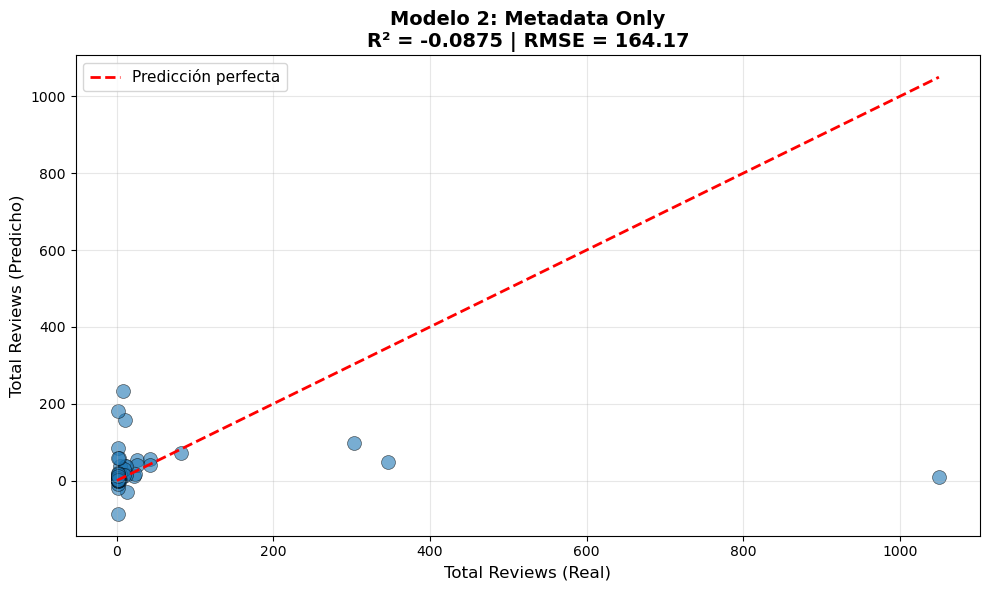


📊 RESUMEN - Modelo 2: Metadata Only
Features: price, early_access, num_genres, num_tags, num_specs, has_sentiment
          (6 dimensiones de metadata)
Train: 3057 juegos (antes de 2017-01-01)
Test: 50 juegos (2017 en adelante)

Resultados:
  R² = -0.0875
  RMSE = 164.17


In [5]:
import matplotlib.pyplot as plt

# Crear gráfico de predicciones
plt.figure(figsize=(10, 6))
plt.scatter(y_test_temporal, pred_temporal, alpha=0.6, s=100, edgecolors='k', linewidth=0.5)
plt.plot([0, y_test_temporal.max()], [0, y_test_temporal.max()], 'r--', lw=2, label='Predicción perfecta')
plt.xlabel('Total Reviews (Real)', fontsize=12)
plt.ylabel('Total Reviews (Predicho)', fontsize=12)
plt.title(f'Modelo 2: Metadata Only\nR² = {r2_temporal:.4f} | RMSE = {rmse_temporal:.2f}', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("📊 RESUMEN - Modelo 2: Metadata Only")
print("="*70)
print(f"Features: price, early_access, num_genres, num_tags, num_specs, has_sentiment")
print(f"          (6 dimensiones de metadata)")
print(f"Train: {len(X_train_temporal)} juegos (antes de 2017-01-01)")
print(f"Test: {len(X_test_temporal)} juegos (2017 en adelante)")
print(f"\nResultados:")
print(f"  R² = {r2_temporal:.4f}")
print(f"  RMSE = {rmse_temporal:.2f}")
print("="*70)